# 入出力があるデータの可視化

統計モデルを構築する際、データの生成メカニズムが既知であれば、メカニズムをそのままモデル式に落とし込めます。しかしながら実際のモデル検討では多くの場合、説明変数と応答変数の関係が不明な状態から出発します。そこで2章で扱った可視化やEDAを用いて、モデル構造の当たりをつけることが重要となります。

例えば2章で紹介したpairplotは、変数間の相関や分布形状を一度に概観でき、入出力があるデータでも有効です。以下に書籍7.2.5項で生成したサンプルデータセットをpairplotで可視化する例を示します。

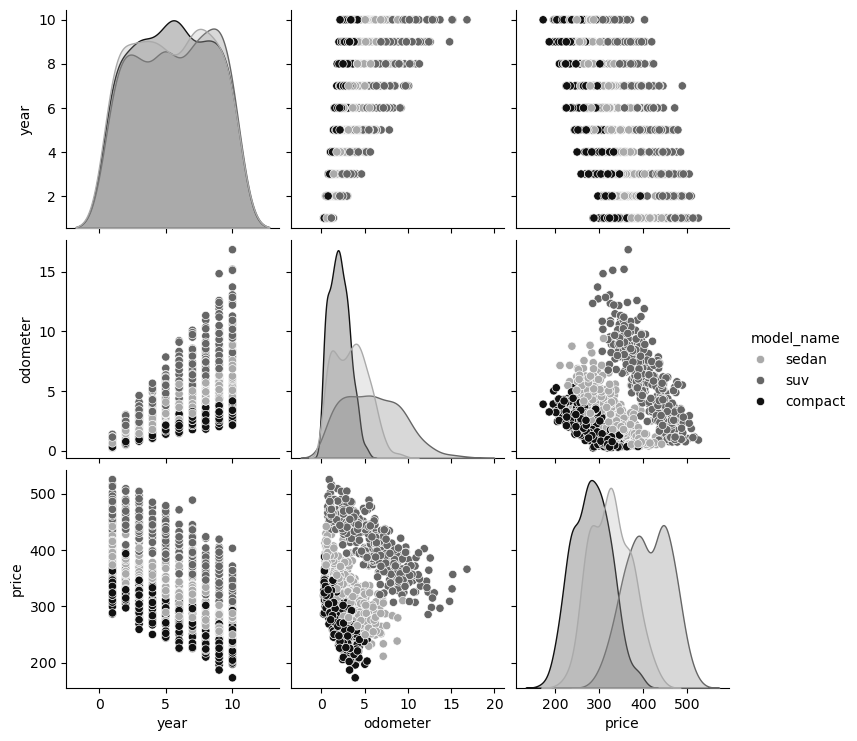

In [1]:
# コード7.4 pairplot による入出力があるデータの可視化
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSVからPandas DataFrameにデータ読み込み（正常データのみ使用）
df = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/usedcar_dataset_train.csv')
df_normal = df[df['label'] == 'normal']
# pairplotによる可視化
sns.pairplot(
    data=df_normal, # DataFrame
    hue='model_name', # 色分け対象の列名
    palette=['#aaaaaa', '#666666', '#111111'] # 色分けのカラーパレット
)
plt.show()

最下段の散布図から、応答変数である中古車価格（`price`） と他の説明変数（数値変数`year`、`odometer`）との関係を見ると、おおむね線形の関係が確認できます。したがって、データ生成時ののような複雑な階層構造を用いなくとも、一般化線形モデル（GLM）のようなシンプルなモデルで挙動をある程度正確に表現できる見通しが立ちます。

pairplot以外にも入出力があるデータに対して有用な可視化手法として、単回帰直線と箱ひげ図を用いた方法を以下に示します。

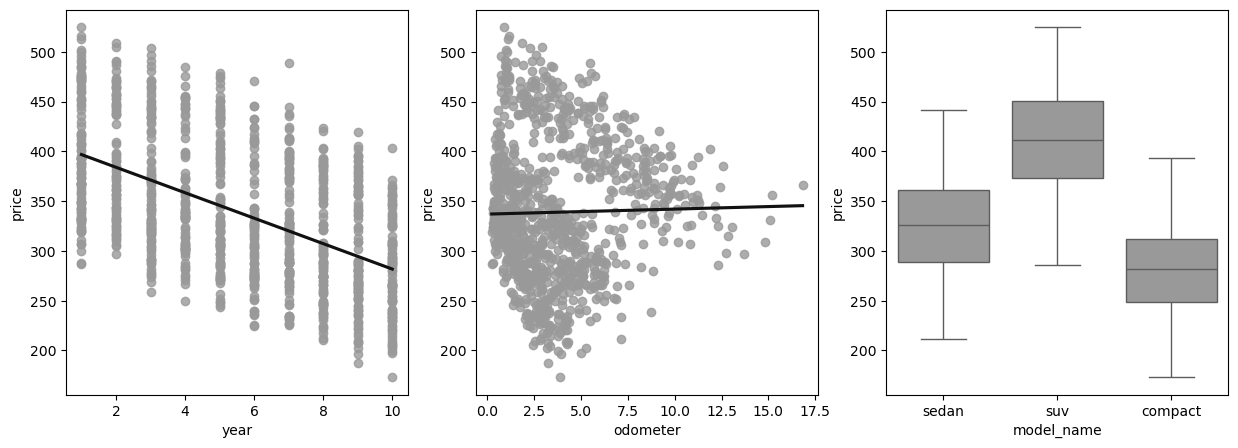

In [2]:
# コード7.5 箱ひげ図と単回帰直線による入出力があるデータの可視化
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
# regplotによる単回帰直線と散布図の描画
for i, colname in enumerate(['year', 'odometer']):
    sns.regplot(
        data=df_normal, # DataFrame
        x=colname, # 横軸とする説明変数名
        y='price', # 縦軸とする応答変数名
        scatter_kws={'color':'#999999'}, # 点の色
        line_kws={'color':'#111111'}, # 線の色
        ci=None, # 回帰直線の信頼区間の表示の有無
        ax=axes[i] # 描画対象のAxes
        )
# boxplotによる箱ひげ図の描画
sns.boxplot(
    data=df_normal, # DataFrame
    x='model_name', # 横軸とするカテゴリ説明変数名
    y='price', # 縦軸とする応答変数名
    color='#999999', # 塗りつぶし色
    ax=axes[2], # 描画対象のAxes
)
plt.show()

単回帰直線は説明変数（数値）による応答変数の変化の把握に、箱ひげ図は説明変数（カテゴリ）による応答変数の分布の差の把握に、それぞれ効果的であることがわかります。